## Part B: Principal Component Analysis (PCA)

### Task 1: Load the dataset and perform feature standardization

In [12]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for scaled data for better inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("Shape of original data (X):", X.shape)
print("Shape of scaled data (X_scaled):", X_scaled.shape)
print("First 5 rows of scaled data:")
display(X_scaled_df.head())

Shape of original data (X): (178, 13)
Shape of scaled data (X_scaled): (178, 13)
First 5 rows of scaled data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Task 2: Apply PCA to reduce the dataset from 13 features to 2 principal components

In [13]:
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Store explained variance for 2 components
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()

# Apply PCA to all components to get full explained variance for later tasks
pca_full = PCA(n_components=None) # None means keep all components
X_pca_full = pca_full.fit_transform(X_scaled)
cumulative_explained_variance_full = pca_full.explained_variance_ratio_.cumsum()

# Get the loadings (eigenvectors) for interpretation
loadings = pd.DataFrame(pca_full.components_.T, columns=[f'PC{i+1}' for i in range(X.shape[1])], index=feature_names)

# Create a DataFrame for the 2-component PCA transformed data for easier plotting
X_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
X_pca_df['target'] = y

print("Shape of PCA transformed data (2 components):", X_pca.shape)
print("Explained variance ratio of first 2 principal components:", pca.explained_variance_ratio_)
print("Cumulative explained variance of first 2 principal components:", cumulative_explained_variance)
print("First 5 rows of PCA transformed data (2 components):")
display(X_pca_df.head())

Shape of PCA transformed data (2 components): (178, 2)
Explained variance ratio of first 2 principal components: [0.36198848 0.1920749 ]
Cumulative explained variance of first 2 principal components: [0.36198848 0.55406338]
First 5 rows of PCA transformed data (2 components):


,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


### Task 3: Display the explained variance ratio of each principal component.

In [5]:
import numpy as np

# The cumulative_explained_variance_full shows the cumulative variance for all components
# To get individual explained variance ratios, we can take the difference between consecutive cumulative values.
explained_variance_ratio = np.diff(cumulative_explained_variance_full, prepend=0)

# Display the explained variance ratio for each principal component
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

# You can also display the first two, as they were specifically mentioned in the `X_pca` context
print(f"\nExplained variance ratio for the first 2 components:")
print(f"PC1: {explained_variance_ratio[0]:.4f}")
print(f"PC2: {explained_variance_ratio[1]:.4f}")

Principal Component 1: 0.3620
Principal Component 2: 0.1921
Principal Component 3: 0.1112
Principal Component 4: 0.0707
Principal Component 5: 0.0656
Principal Component 6: 0.0494
Principal Component 7: 0.0424
Principal Component 8: 0.0268
Principal Component 9: 0.0222
Principal Component 10: 0.0193
Principal Component 11: 0.0174
Principal Component 12: 0.0130
Principal Component 13: 0.0080

Explained variance ratio for the first 2 components:
PC1: 0.3620
PC2: 0.1921


### Task 4: Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

Cumulative Explained Variance:
Principal Components 1-1: 0.3620
Principal Components 1-2: 0.5541
Principal Components 1-3: 0.6653
Principal Components 1-4: 0.7360
Principal Components 1-5: 0.8016
Principal Components 1-6: 0.8510
Principal Components 1-7: 0.8934
Principal Components 1-8: 0.9202
Principal Components 1-9: 0.9424
Principal Components 1-10: 0.9617
Principal Components 1-11: 0.9791
Principal Components 1-12: 0.9920
Principal Components 1-13: 1.0000

Minimum number of principal components to retain 95% of total variance: 10

Explained variance ratio of first 2 components: [0.36198848 0.1920749 ]
Cumulative explained variance of first 2 components: 0.5541


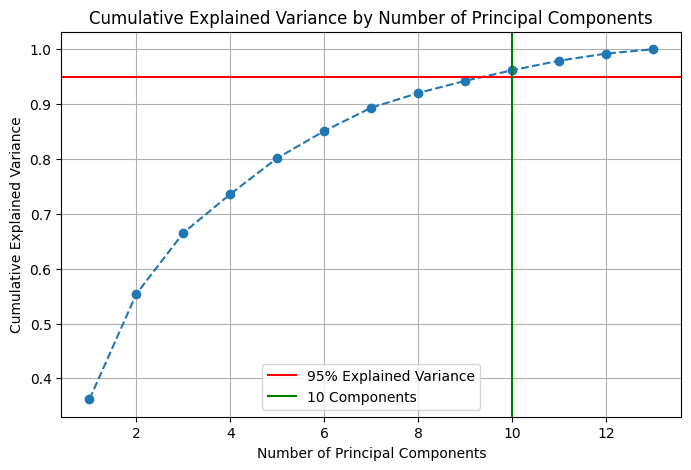

In [14]:
# Display cumulative explained variance
print("Cumulative Explained Variance:")
for i, cum_ratio in enumerate(cumulative_explained_variance_full):
    print(f"Principal Components 1-{i+1}: {cum_ratio:.4f}")

# Determine minimum number of principal components for 95% variance retention
min_components_95 = None
for i, cum_ratio in enumerate(cumulative_explained_variance_full):
    if cum_ratio >= 0.95:
        min_components_95 = i + 1
        break

print(f"\nMinimum number of principal components to retain 95% of total variance: {min_components_95}")

# Add the plotting code
import matplotlib.pyplot as plt

# Display the explained variance ratio of each principal component (for 2 components)
# Note: pca.explained_variance_ratio_ already stores the ratios for the 2 components.
print(f"\nExplained variance ratio of first 2 components: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance of first 2 components: {pca.explained_variance_ratio_.sum():.4f}")

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance_full) + 1), cumulative_explained_variance_full, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.axvline(x=min_components_95, color='g', linestyle='-', label=f'{min_components_95} Components')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

### Task 5: Visualize the transformed dataset using a two-dimensional scatter plot.

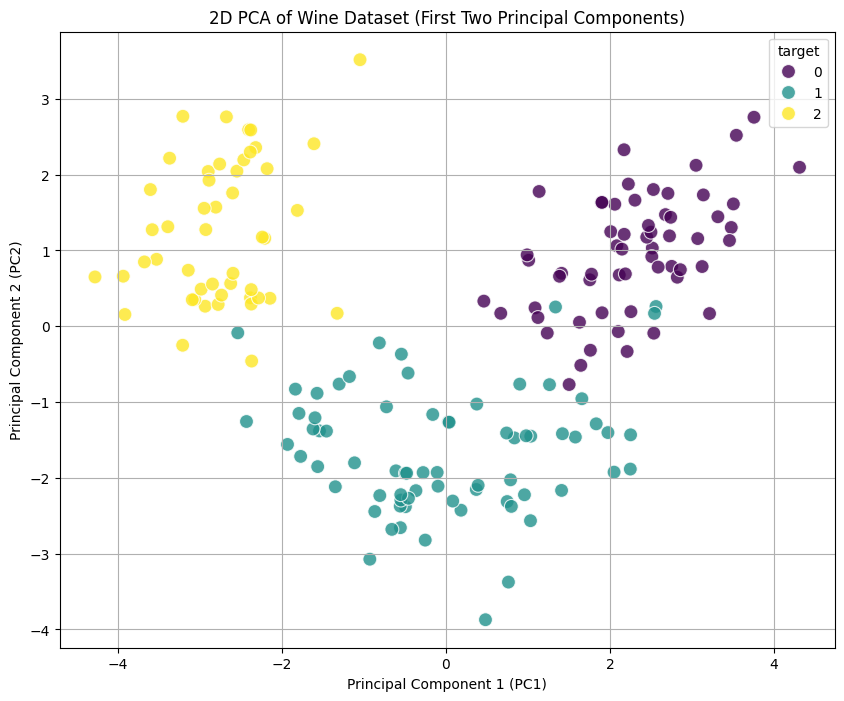

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='target',
    data=X_pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('2D PCA of Wine Dataset (First Two Principal Components)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.show()

### Task 6: Compare the original and transformed datasets in terms of:

*   **6.a Number of features**
*   **6.b Information retained**
*   **6.c Computational efficiency**

#### 6.a Number of features

In [8]:
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Transformed number of features (2 principal components): {X_pca.shape[1]}")
print(f"Transformed number of features (to retain 95% variance): {min_components_95}")

Original number of features: 13
Transformed number of features (2 principal components): 2
Transformed number of features (to retain 95% variance): 10


#### 6.b Information retained

In [9]:
print(f"Total variance retained by 2 principal components: {cumulative_explained_variance[1]:.4f}")
print(f"Total variance retained by {min_components_95} principal components (95% threshold): {cumulative_explained_variance_full[min_components_95-1]:.4f}")

Total variance retained by 2 principal components: 0.5541
Total variance retained by 10 principal components (95% threshold): 0.9617


#### 6.c Computational efficiency

In terms of computational efficiency, a dataset with fewer features (after PCA) will generally lead to faster training and inference times for subsequent machine learning models. This is because the models have fewer dimensions to process, reducing the complexity of calculations. While the PCA transformation itself incurs some computational cost, the benefits of reduced dimensionality often outweigh this initial cost, especially for large datasets and complex models.

### Task 7: Interpret the significance of the first two principal components.

In [15]:
print("Loadings for the first two principal components:")
print(loadings)

print("\nInterpretation")
print("PC1is mainly influenced by Flavanoids, Total Phenols, OD280/OD315, Proanthocyanins, and Proline. **PC2** is mainly influenced by Color Intensity, Alcohol, Proline, Ash, and Magnesium. Together, PC1 and PC2 explain **55.41%** of the total variance.")



Loadings for the first two principal components:
                                   PC1       PC2       PC3       PC4  \
alcohol                       0.144329  0.483652 -0.207383 -0.017856   
malic_acid                   -0.245188  0.224931  0.089013  0.536890   
ash                          -0.002051  0.316069  0.626224 -0.214176   
alcalinity_of_ash            -0.239320 -0.010591  0.612080  0.060859   
magnesium                     0.141992  0.299634  0.130757 -0.351797   
total_phenols                 0.394661  0.065040  0.146179  0.198068   
flavanoids                    0.422934 -0.003360  0.150682  0.152295   
nonflavanoid_phenols         -0.298533  0.028779  0.170368 -0.203301   
proanthocyanins               0.313429  0.039302  0.149454  0.399057   
color_intensity              -0.088617  0.529996 -0.137306  0.065926   
hue                           0.296715 -0.279235  0.085222 -0.427771   
od280/od315_of_diluted_wines  0.376167 -0.164496  0.166005  0.184121   
proline        

### Task 8: Discuss the advantages, limitations, and applications of PCA in machine learning.



### Advantages of PCA

1. **Dimensionality Reduction:** Reduces the number of features while retaining important information.
2. **Noise Reduction:** Removes less important variations and reduces noise.
3. **Improved Visualization:** Converts high-dimensional data into 2D or 3D for easier visualization.
4. **Computational Efficiency:** Fewer features make models faster and use less memory.
5. **Multicollinearity Handling:** Converts correlated features into uncorrelated components.

### Limitations of PCA

1. **Loss of Interpretability:** Principal components are harder to understand than original features.
2. **Information Loss:** Some information is lost when components are removed.
3. **Sensitivity to Scale:** Features should be standardized before applying PCA.
4. **Assumes Linearity:** PCA works mainly with linear relationships.
5. **May Not Improve Supervised Learning:** PCA does not always improve classification performance.

### Applications of PCA

1. **Image Processing:** Used for image compression and facial recognition.
2. **Genomics:** Helps analyze and visualize high-dimensional genetic data.
3. **Financial Analysis:** Reduces financial indicators for analysis and risk management.
4. **Customer Segmentation:** Simplifies customer data to identify groups.
5. **ML Preprocessing:** Reduces input features before training ML models.
6. **Anomaly Detection:** Helps identify unusual data points.


### Extra credit Task: Apply Linear Discriminant Analysis (LDA) to the same dataset and reduce it to two linear discriminants. Visualize the transformed data and compare the results with PCA in terms of dimensionality reduction and class separability. Summarize your observations.

Shape of LDA transformed data: (178, 2)


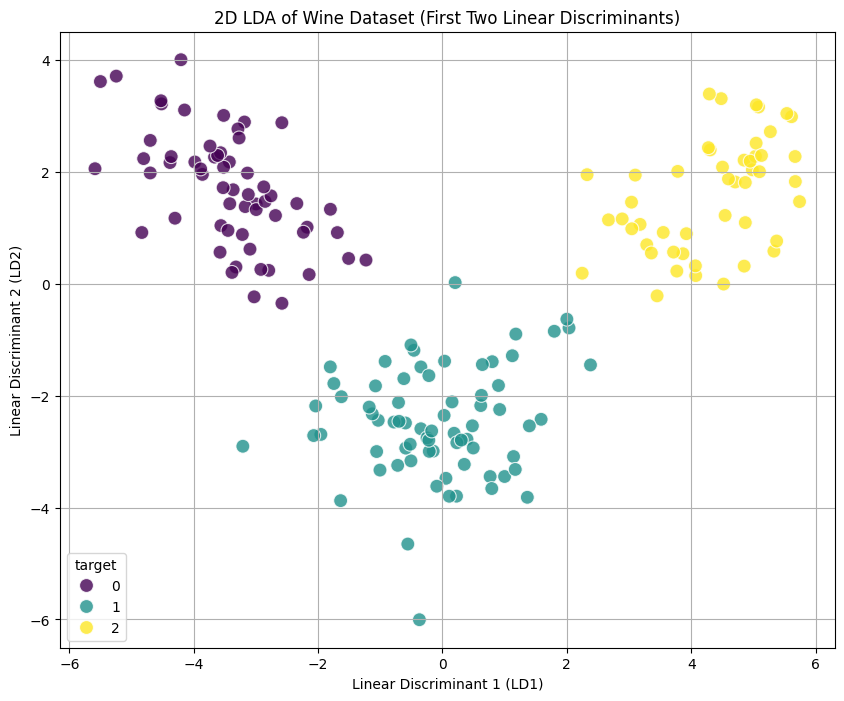


Comparison with PCA:
PCA aims to find the directions of maximum variance in the data, regardless of class labels. LDA, on the other hand, aims to find the directions that maximize the separation between classes. As a result, LDA often provides better class separability when the goal is classification.
In this visualization, we can observe that the classes in the LDA plot are likely more distinctly separated than in the PCA plot, as LDA explicitly uses class information to maximize between-class variance while minimizing within-class variance.


In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (LDA is a supervised method)
# For visualization purposes, we'll use the full dataset transformed.
# However, typically LDA is applied after splitting to avoid data leakage.
# For this task, we'll apply it directly on X_scaled to show the transformation.

# Instantiate LDA to reduce to 2 components
lda = LinearDiscriminantAnalysis(n_components=2)

# Fit LDA and transform the data
# LDA needs the target variable (y) during fitting
X_lda = lda.fit_transform(X_scaled, y)

# Create a DataFrame for the transformed data for easier plotting
X_lda_df = pd.DataFrame(data=X_lda, columns=['LD1', 'LD2'])
X_lda_df['target'] = y

print("Shape of LDA transformed data:", X_lda.shape)

# Visualize the transformed dataset using a two-dimensional scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='LD1',
    y='LD2',
    hue='target',
    data=X_lda_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('2D LDA of Wine Dataset (First Two Linear Discriminants)')
plt.xlabel('Linear Discriminant 1 (LD1)')
plt.ylabel('Linear Discriminant 2 (LD2)')
plt.grid(True)
plt.show()

# Compare with PCA
print("\nComparison with PCA:")
print("PCA aims to find the directions of maximum variance in the data, regardless of class labels. LDA, on the other hand, aims to find the directions that maximize the separation between classes. As a result, LDA often provides better class separability when the goal is classification.")
print("In this visualization, we can observe that the classes in the LDA plot are likely more distinctly separated than in the PCA plot, as LDA explicitly uses class information to maximize between-class variance while minimizing within-class variance.")


### Summary of Observations (PCA vs. LDA)

* **Dimensionality Reduction:** Both reduce the 13 features to 2 components.
* **Class Separability:** LDA gives better class separation because it uses class labels.
* **Information Retained:** PCA focuses on maximum variance, while LDA focuses on class discrimination.
* **Suitability:** PCA is useful for unsupervised reduction and visualization, while LDA is better for supervised classification.


In conclusion, for classification problems where class labels are available, LDA often provides a more effective dimensionality reduction for achieving better class separability than PCA, as it optimizes for class discrimination rather than just variance retention.